<a href="https://colab.research.google.com/github/2405301105-tech/Gen-ai-and-Agentic-ai/blob/main/multiplemodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain-google-genai langchain langchain-groq gtts matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.4.1
    Uninstalling click-8.4.1:
      Successfully uninstalled click-8.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.27.2 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.19.0 requires click>=8.4.0, but you have click 8.1.8 which is incompatible.
typer 0.25.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [ ]:

import os
import base64
import json
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from groq import Groq
from langchain.agents import create_agent
from langchain.tools import tool
from gtts import gTTS
import matplotlib.pyplot as plt
from dotenv import load_dotenv

In [ ]:
load_dotenv()


True

In [ ]:
with open("/content/blood_work.png","rb")as f:
  image_encoded=base64.b64encode(f.read()).decode()

In [ ]:
llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [ ]:
from langchain_core.messages import HumanMessage

In [ ]:
message=HumanMessage(content=[
    {"type":"image_url","image_url":{"url":f"data:image/png;base64,{image_encoded}"}},
    {"type":"text","text":"Extract all result the text from the given image carefully remember there should not be any error"}
])

In [ ]:
responses=llm.invoke([message])

In [ ]:
text_llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [ ]:
summary_prompt=f"Summarize this given blood report in a simple language so that a normal human can understand this blood report: {responses}"
summery_report=text_llm.invoke(summary_prompt).content

In [ ]:
tts=gTTS(text=summery_report,lang="en")
tts.save("report.mp3")

In [ ]:
from IPython.display import Audio

In [ ]:
Audio("report.mp3")

In [ ]:
blood_data = {
    "Hemoglobin":        {"value": 15.1, "low": 13.5, "high": 17.5},
    "Total Cholesterol": {"value": 238,  "low": 0,    "high": 200},
    "LDL Cholesterol":   {"value": 162,  "low": 0,    "high": 100},
    "HDL Cholesterol":   {"value": 36,   "low": 40,   "high": 100},
    "Triglycerides":     {"value": 188,  "low": 0,    "high": 150},
    "Glucose":           {"value": 92,   "low": 70,   "high": 99},
    "HbA1c":             {"value": 5.3,  "low": 0,    "high": 5.7},
    "Creatinine":        {"value": 1.0,  "low": 0.7,  "high": 1.3},
}
tests=list(blood_data.keys())

In [ ]:
values=[d["value"] for d in blood_data.values()]

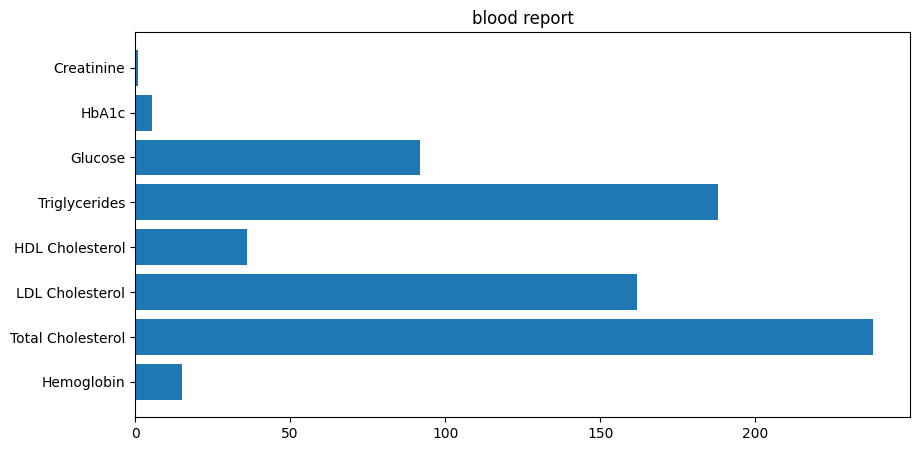

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(tests,values)
plt.title("blood report")
plt.savefig("chart.png")
plt.show()

In [ ]:
questions=gTTS(text="how should we handle High cholestrol",lang="en").save("question.mp3")

In [ ]:
Audio("question.mp3")

In [ ]:
client=Groq()

In [ ]:
with open("question.mp3", "rb") as f:
    transcribe=client.audio.transcriptions.create(
        file=("question.mp3", f.read()),
        model="whisper-large-v3"
    )

In [36]:
t=transcribe.text

In [37]:
t

' How should we handle high cholesterol?'

In [35]:
import base64
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

@tool
def analyze_image(image_path: str) -> str:
    """Analyze an image using the vision LLM. Pass a file path like 'blood_work.png'.
    Returns extracted text description of the image contents."""
    with open(image_path, "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode()
    vlm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
    msg = HumanMessage(content=[
        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
        {"type": "text", "text": "Extract and describe all information from this image."}
    ])
    return vlm.invoke([msg]).content

In [38]:
@tool
def transcribe_audio(audio_path: str) -> str:
    """Transcribe an audio file to text using Whisper. Pass a file path like 'question.mp3'.
    Returns the transcribed text."""
    client = Groq()
    with open(audio_path, "rb") as f:
        result = client.audio.transcriptions.create(
            file=(audio_path, f.read()),
            model="whisper-large-v3",
        )
    return result.text

In [39]:
@tool
def generate_chart(title: str, labels: str, values: str) -> str:
    """Generate a bar chart and save as 'agent_chart.png'.
    - title: chart title
    - labels: comma-separated labels like 'LDL,HDL,Triglycerides'
    - values: comma-separated numbers like '162,36,188'
    Returns confirmation message."""
    plt.barh(labels.split(","), [float(v) for v in values.split(",")], color="#e74c3c")
    plt.title(title)
    plt.savefig("agent_chart.png", bbox_inches="tight")
    plt.close()
    return "Chart saved to agent_chart.png"